# Dome Flow Estimation from Louvers, Shutter, and Anemometers

This notebook builds a bulk-flow estimate for the dome using:

- Outside wind from `lsst.sal.ESS.airFlow` index 301
- Mount anemometers from `lsst.sal.ESS.airTurbulence` indices 110 and 123-126
- Dome azimuth from `lsst.sal.MTDome.azimuth`
- Shutter opening from `lsst.sal.MTDome.apertureShutter`
- A user-supplied 34-louver geometry map with azimuths and full-open areas

The intent is to compare an internal flow proxy from the mount anemometers against an outside forcing term based on wind speed times effective open area.

This is not a CFD model. It is a controllable first-order exchange model that gives you something you can calibrate and stress-test quickly.

## Model Summary

For each timestamp, the notebook computes:

- Windward louver area: the sum of louver areas facing the incoming wind
- Leeward louver area: the sum of louver areas facing away from the incoming wind
- Shutter area contribution from the measured shutter opening fraction
- Effective through area: `min(A_in, A_out)` as a bottleneck approximation
- Outside driver: `U_out * A_eff`
- Inside flow proxy: mean or median mount-anemometer speed

If you also provide an internal reference area, the notebook converts the inside proxy to an estimated volumetric flow and fits an effective discharge coefficient.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from pathlib import Path
from IPython.display import display

from astropy.time import Time, TimeDelta
import astropy.units as u

from lsst_efd_client import EfdClient

%matplotlib inline

In [3]:
EFD_ALIAS = "usdf_efd"

t_end = Time("2026-03-15T05:00:00", scale="utc")
t_start = t_end - TimeDelta(7 * u.day)

RESAMPLE_RULE = "30s"
MIN_INSIDE_SENSORS = 3

flow_topic = "lsst.sal.ESS.airFlow"
turb_topic = "lsst.sal.ESS.airTurbulence"
dome_topic = "lsst.sal.MTDome.azimuth"
shutter_topic = "lsst.sal.MTDome.apertureShutter"

weather_index = 301
speed_field = "speedMagnitude"
outside_speed_field = "speed"
outside_direction_field = "direction"
dome_azimuth_field = "positionActual"
shutter_fields = ["positionActual0", "positionActual1"]

ess_sensors = {
    110: "TMA Platform",
    123: "Top Ring -X/-Y",
    124: "Top Ring +X/-Y",
    125: "Top Ring +X/+Y",
    126: "Top Ring -X/+Y",
}

speed_clip = {
    110: None,
    123: 8.6,
    124: 8.6,
    125: 8.6,
    126: 8.6,
}

# Geometry / calibration parameters. Replace these with measured values.
SHUTTER_FULL_OPEN_AREA_M2 = 200.0
SHUTTER_AZIMUTH_OFFSET_DEG = 0.0
INTERNAL_REFERENCE_AREA_M2 = np.nan
INITIAL_DISCHARGE_COEFFICIENT = 1.0

print(f"Start: {t_start.iso}")
print(f"End:   {t_end.iso}")
print(f"Resample rule: {RESAMPLE_RULE}")

Start: 2026-03-08 05:00:00.000
End:   2026-03-15 05:00:00.000
Resample rule: 30s


## Louver Geometry Input

The notebook looks for a file named `louver_map.csv` in the working directory. If it does not exist, it creates a 34-row template.

Required columns:

- `louver_id`: label such as `L01`
- `azimuth_dome_deg`: louver outward normal in dome coordinates, degrees
- `full_open_area_m2`: full-open geometric area in square meters
- `open_fraction`: static opening fraction between 0 and 1 for the analysis window

If only some louvers are open, set the others to `0.0`.

In [4]:
louver_map_path = Path("louver_map.csv")

if louver_map_path.exists():
    louver_map = pd.read_csv(louver_map_path)
else:
    louver_map = pd.DataFrame({
        "louver_id": [f"L{i:02d}" for i in range(1, 35)],
        "azimuth_dome_deg": [np.nan] * 34,
        "full_open_area_m2": [np.nan] * 34,
        "open_fraction": [1.0] * 34,
    })

display(louver_map)
print()
print("If the azimuth and area columns are NaN, replace them with your 34-louver map or create louver_map.csv.")
print("The notebook will stop with a clear validation error until those values are filled.")

,index,louver_id,louver_type,full_open_area_m2,azimuth_dome_deg,open_fraction
0,0,A1,1,13.00,53.10,0.0
1,1,A2,7,5.04,53.10,0.0
2,2,B1,1,13.00,67.50,1.0
3,3,B2,1,13.00,67.50,0.0
4,4,B3,4,9.03,67.50,0.0
5,5,C1,1,13.00,95.50,0.0
6,6,C2,1,13.00,95.50,0.0
7,7,C3,1,13.00,95.50,0.0
8,8,D1,2,9.87,120.75,0.0
9,9,D2,2,9.87,120.75,0.0



If the azimuth and area columns are NaN, replace them with your 34-louver map or create louver_map.csv.
The notebook will stop with a clear validation error until those values are filled.


In [5]:
def wrap180(angle_deg):
    angle_deg = np.asarray(angle_deg, dtype=float)
    return (angle_deg + 180.0) % 360.0 - 180.0


def circular_mean_deg(values):
    values = pd.Series(values).dropna().astype(float)
    if values.empty:
        return np.nan
    radians = np.deg2rad(values.to_numpy())
    return np.mod(np.rad2deg(np.arctan2(np.sin(radians).mean(), np.cos(radians).mean())), 360.0)


def validate_geometry(louver_map, shutter_full_open_area_m2):
    required_cols = ["louver_id", "azimuth_dome_deg", "full_open_area_m2", "open_fraction"]
    missing_cols = [col for col in required_cols if col not in louver_map.columns]
    if missing_cols:
        raise ValueError(f"louver_map is missing columns: {missing_cols}")

    if len(louver_map) != 34:
        raise ValueError(f"Expected 34 louvers, found {len(louver_map)}")

    if louver_map[["azimuth_dome_deg", "full_open_area_m2", "open_fraction"]].isna().any().any():
        raise ValueError(
            "Fill azimuth_dome_deg, full_open_area_m2, and open_fraction for all 34 louvers before running the model cells."
        )

    if (louver_map["open_fraction"] < 0).any() or (louver_map["open_fraction"] > 1).any():
        raise ValueError("open_fraction must be between 0 and 1")

    if not np.isfinite(shutter_full_open_area_m2) or shutter_full_open_area_m2 <= 0:
        raise ValueError("Set SHUTTER_FULL_OPEN_AREA_M2 to the full-open shutter aperture area in m^2")


def resample_direction(series, rule):
    return series.resample(rule).apply(circular_mean_deg)


def prepare_inside_sensor(df, sensor_idx, label, clip_threshold, rule):
    speed = df[speed_field].astype(float).copy()
    if clip_threshold is not None:
        speed = speed.where(speed < clip_threshold)
    speed = speed.resample(rule).mean()
    speed.name = f"{sensor_idx}_{label}"
    return speed


def compute_effective_areas(frame, louver_map, shutter_full_open_area_m2, shutter_azimuth_offset_deg):
    louver_angles = louver_map["azimuth_dome_deg"].to_numpy(dtype=float)
    louver_areas = (
        louver_map["full_open_area_m2"].to_numpy(dtype=float)
        * louver_map["open_fraction"].to_numpy(dtype=float)
    )

    windward_area = np.full(len(frame), np.nan)
    leeward_area = np.full(len(frame), np.nan)
    shutter_area = np.full(len(frame), np.nan)
    effective_through_area = np.full(len(frame), np.nan)

    wind_dir = frame["outside_wind_dir_deg"].to_numpy(dtype=float)
    dome_az = frame["dome_azimuth_deg"].to_numpy(dtype=float)
    shutter_frac = frame["shutter_open_fraction"].to_numpy(dtype=float)

    for i in range(len(frame)):
        if not np.isfinite(wind_dir[i]) or not np.isfinite(dome_az[i]) or not np.isfinite(shutter_frac[i]):
            continue

        global_louver_angles = dome_az[i] + louver_angles
        rel = wrap180(wind_dir[i] - global_louver_angles)
        projection = np.cos(np.deg2rad(rel))

        a_in_louver = np.sum(louver_areas * np.clip(projection, 0, None))
        a_out_louver = np.sum(louver_areas * np.clip(-projection, 0, None))

        shutter_angle = dome_az[i] + shutter_azimuth_offset_deg
        shutter_rel = wrap180(wind_dir[i] - shutter_angle)
        shutter_proj = np.cos(np.deg2rad(shutter_rel))
        a_shutter = shutter_full_open_area_m2 * shutter_frac[i]

        a_in_shutter = a_shutter * max(shutter_proj, 0.0)
        a_out_shutter = a_shutter * max(-shutter_proj, 0.0)

        a_in = a_in_louver + a_in_shutter
        a_out = a_out_louver + a_out_shutter

        windward_area[i] = a_in
        leeward_area[i] = a_out
        shutter_area[i] = a_shutter
        effective_through_area[i] = min(a_in, a_out)

    result = frame.copy()
    result["windward_open_area_m2"] = windward_area
    result["leeward_open_area_m2"] = leeward_area
    result["shutter_open_area_m2"] = shutter_area
    result["effective_through_area_m2"] = effective_through_area
    result["outside_driver_m3s_cd1"] = result["outside_wind_speed_mps"] * result["effective_through_area_m2"]
    return result

In [6]:
validate_geometry(louver_map, SHUTTER_FULL_OPEN_AREA_M2)
print("Geometry validation passed.")
print(f"Total static louver area at current open fractions: {np.sum(louver_map['full_open_area_m2'] * louver_map['open_fraction']):.3f} m^2")

Geometry validation passed.
Total static louver area at current open fractions: 65.480 m^2


In [7]:
client = EfdClient(EFD_ALIAS)
print(f"Connected to {EFD_ALIAS}")

df_weather = await client.select_time_series(
    flow_topic,
    fields=[outside_speed_field, outside_direction_field],
    start=t_start,
    end=t_end,
    index=weather_index,
)

df_dome = await client.select_time_series(
    dome_topic,
    fields=[dome_azimuth_field],
    start=t_start,
    end=t_end,
)

df_shutter = await client.select_time_series(
    shutter_topic,
    fields=shutter_fields,
    start=t_start,
    end=t_end,
)

inside_raw = {}
for sensor_idx, label in ess_sensors.items():
    inside_raw[sensor_idx] = await client.select_time_series(
        turb_topic,
        fields=[speed_field],
        start=t_start,
        end=t_end,
        index=sensor_idx,
    )

print(f"Weather rows: {len(df_weather)}")
print(f"Dome azimuth rows: {len(df_dome)}")
print(f"Shutter rows: {len(df_shutter)}")
for sensor_idx, label in ess_sensors.items():
    print(f"Inside sensor {sensor_idx:3d} {label:16s}: {len(inside_raw[sensor_idx])} rows")

Connected to usdf_efd
Weather rows: 472519
Dome azimuth rows: 735743
Shutter rows: 294295
Inside sensor 110 TMA Platform    : 120853 rows
Inside sensor 123 Top Ring -X/-Y  : 120854 rows
Inside sensor 124 Top Ring +X/-Y  : 120852 rows
Inside sensor 125 Top Ring +X/+Y  : 120853 rows
Inside sensor 126 Top Ring -X/+Y  : 120853 rows


In [8]:
weather_aligned = pd.DataFrame({
    "outside_wind_speed_mps": df_weather[outside_speed_field].astype(float).resample(RESAMPLE_RULE).mean(),
    "outside_wind_dir_deg": resample_direction(df_weather[outside_direction_field], RESAMPLE_RULE),
})

dome_aligned = pd.DataFrame({
    "dome_azimuth_deg": resample_direction(df_dome[dome_azimuth_field], RESAMPLE_RULE),
})

shutter_aligned = df_shutter[shutter_fields].astype(float).resample(RESAMPLE_RULE).mean().rename(
    columns={
        "positionActual0": "shutter_left_pct",
        "positionActual1": "shutter_right_pct",
    }
)
shutter_aligned["shutter_open_fraction"] = (
    0.5 * (shutter_aligned["shutter_left_pct"] + shutter_aligned["shutter_right_pct"]) / 100.0
)

inside_series = []
for sensor_idx, label in ess_sensors.items():
    sensor_series = prepare_inside_sensor(
        inside_raw[sensor_idx],
        sensor_idx=sensor_idx,
        label=label.replace(" ", "_"),
        clip_threshold=speed_clip[sensor_idx],
        rule=RESAMPLE_RULE,
    )
    inside_series.append(sensor_series)

inside_aligned = pd.concat(inside_series, axis=1)
inside_aligned["inside_speed_mean_mps"] = inside_aligned.mean(axis=1, skipna=True)
inside_aligned["inside_speed_median_mps"] = inside_aligned.median(axis=1, skipna=True)
inside_aligned["inside_sensor_count"] = inside_aligned.notna().sum(axis=1)

model_df = pd.concat([weather_aligned, dome_aligned, shutter_aligned, inside_aligned], axis=1)
model_df = model_df.sort_index()
model_df = model_df[model_df["inside_sensor_count"] >= MIN_INSIDE_SENSORS].copy()

model_df = compute_effective_areas(
    model_df,
    louver_map=louver_map,
    shutter_full_open_area_m2=SHUTTER_FULL_OPEN_AREA_M2,
    shutter_azimuth_offset_deg=SHUTTER_AZIMUTH_OFFSET_DEG,
)

model_df["inside_flow_proxy_m3s"] = model_df["inside_speed_mean_mps"] * INTERNAL_REFERENCE_AREA_M2
model_df["outside_flow_initial_m3s"] = INITIAL_DISCHARGE_COEFFICIENT * model_df["outside_driver_m3s_cd1"]

print(f"Aligned samples after sensor-count filter: {len(model_df)}")
display(model_df.head())

Aligned samples after sensor-count filter: 20160


,outside_wind_speed_mps,outside_wind_dir_deg,dome_azimuth_deg,shutter_left_pct,shutter_right_pct,shutter_open_fraction,110_TMA_Platform,123_Top_Ring_-X/-Y,124_Top_Ring_+X/-Y,125_Top_Ring_+X/+Y,...,inside_speed_mean_mps,inside_speed_median_mps,inside_sensor_count,windward_open_area_m2,leeward_open_area_m2,shutter_open_area_m2,effective_through_area_m2,outside_driver_m3s_cd1,inside_flow_proxy_m3s,outside_flow_initial_m3s
2026-03-08 05:00:00+00:00,3.652225,20.532770,328.00293,0.0,0.02,0.0001,0.100297,0.497186,0.134203,0.109593,...,0.271761,0.202982,7,19.895305,26.110240,0.02,19.895305,72.662131,NaN,72.662131
2026-03-08 05:00:30+00:00,3.694983,23.606045,328.00293,0.0,0.02,0.0001,0.097760,0.522207,0.172530,0.133122,...,0.281025,0.226777,7,21.028653,26.799944,0.02,21.028653,77.700509,NaN,77.700509
2026-03-08 05:01:00+00:00,3.878100,22.455491,328.00293,0.0,0.02,0.0001,0.133382,0.317257,0.107938,0.083715,...,0.225328,0.179355,7,20.611270,26.550663,0.02,20.611270,79.932565,NaN,79.932565
2026-03-08 05:01:30+00:00,3.546313,23.314598,328.00293,0.0,0.02,0.0001,0.182192,0.296195,0.182701,0.091959,...,0.252255,0.217478,7,20.923721,26.737817,0.02,20.923721,74.202065,NaN,74.202065
2026-03-08 05:02:00+00:00,3.727617,19.326453,328.00293,0.0,0.02,0.0001,0.184876,0.322982,0.136711,0.169079,...,0.256955,0.220915,7,19.434619,25.818875,0.02,19.434619,72.444823,NaN,72.444823


In [9]:
fit_df = model_df.dropna(
    subset=["outside_wind_speed_mps", "effective_through_area_m2", "inside_speed_mean_mps"]
).copy()
fit_df = fit_df[fit_df["effective_through_area_m2"] > 0].copy()

x = fit_df["outside_driver_m3s_cd1"].to_numpy(dtype=float)
y_speed = fit_df["inside_speed_mean_mps"].to_numpy(dtype=float)

speed_gain = np.dot(x, y_speed) / np.dot(x, x)
fit_df["inside_speed_fit_mps"] = speed_gain * fit_df["outside_driver_m3s_cd1"]
speed_corr = np.corrcoef(x, y_speed)[0, 1] if len(fit_df) > 1 else np.nan

print(f"Samples used for fit: {len(fit_df)}")
print(f"Best-fit speed gain [m/s per (m^3/s at Cd=1)]: {speed_gain:.6f}")
print(f"Correlation between inside speed and outside driver: {speed_corr:.3f}")

if np.isfinite(INTERNAL_REFERENCE_AREA_M2) and INTERNAL_REFERENCE_AREA_M2 > 0:
    y_flow = fit_df["inside_flow_proxy_m3s"].to_numpy(dtype=float)
    fitted_cd = np.dot(x, y_flow) / np.dot(x, x)
    fit_df["outside_flow_fit_m3s"] = fitted_cd * fit_df["outside_driver_m3s_cd1"]
    flow_corr = np.corrcoef(x, y_flow)[0, 1] if len(fit_df) > 1 else np.nan
    print(f"Fitted discharge coefficient: {fitted_cd:.4f}")
    print(f"Correlation in flow units: {flow_corr:.3f}")
else:
    fitted_cd = np.nan
    print("INTERNAL_REFERENCE_AREA_M2 is not set, so the notebook fits only a speed gain and not an absolute flow coefficient.")

Samples used for fit: 14112
Best-fit speed gain [m/s per (m^3/s at Cd=1)]: 0.007704
Correlation between inside speed and outside driver: 0.345
INTERNAL_REFERENCE_AREA_M2 is not set, so the notebook fits only a speed gain and not an absolute flow coefficient.


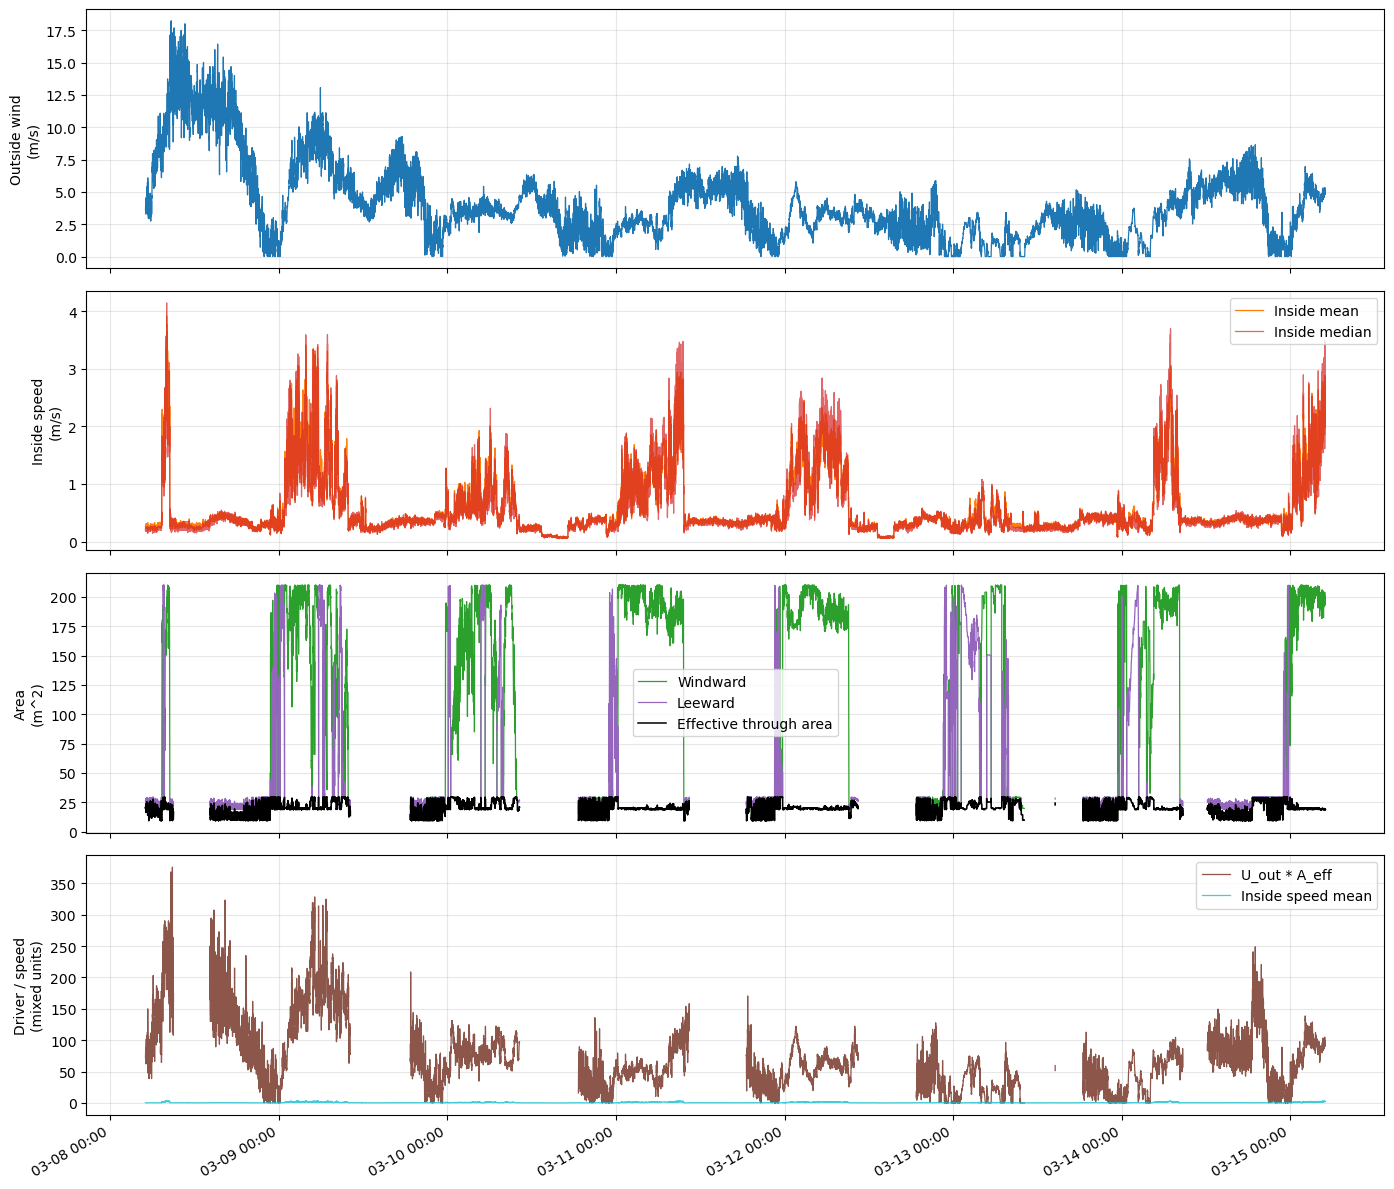

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(model_df.index, model_df["outside_wind_speed_mps"], color="tab:blue", lw=0.9)
axes[0].set_ylabel("Outside wind\n(m/s)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(model_df.index, model_df["inside_speed_mean_mps"], color="tab:orange", lw=0.9, label="Inside mean")
axes[1].plot(model_df.index, model_df["inside_speed_median_mps"], color="tab:red", lw=0.9, alpha=0.7, label="Inside median")
axes[1].set_ylabel("Inside speed\n(m/s)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(model_df.index, model_df["windward_open_area_m2"], color="tab:green", lw=0.9, label="Windward")
axes[2].plot(model_df.index, model_df["leeward_open_area_m2"], color="tab:purple", lw=0.9, label="Leeward")
axes[2].plot(model_df.index, model_df["effective_through_area_m2"], color="black", lw=1.1, label="Effective through area")
axes[2].set_ylabel("Area\n(m^2)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

axes[3].plot(model_df.index, model_df["outside_driver_m3s_cd1"], color="tab:brown", lw=0.9, label="U_out * A_eff")
if np.isfinite(INTERNAL_REFERENCE_AREA_M2) and INTERNAL_REFERENCE_AREA_M2 > 0:
    axes[3].plot(model_df.index, model_df["inside_flow_proxy_m3s"], color="tab:cyan", lw=0.9, alpha=0.8, label="Inside flow proxy")
    axes[3].set_ylabel("Flow proxy\n(m^3/s)")
else:
    axes[3].plot(model_df.index, model_df["inside_speed_mean_mps"], color="tab:cyan", lw=0.9, alpha=0.8, label="Inside speed mean")
    axes[3].set_ylabel("Driver / speed\n(mixed units)")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

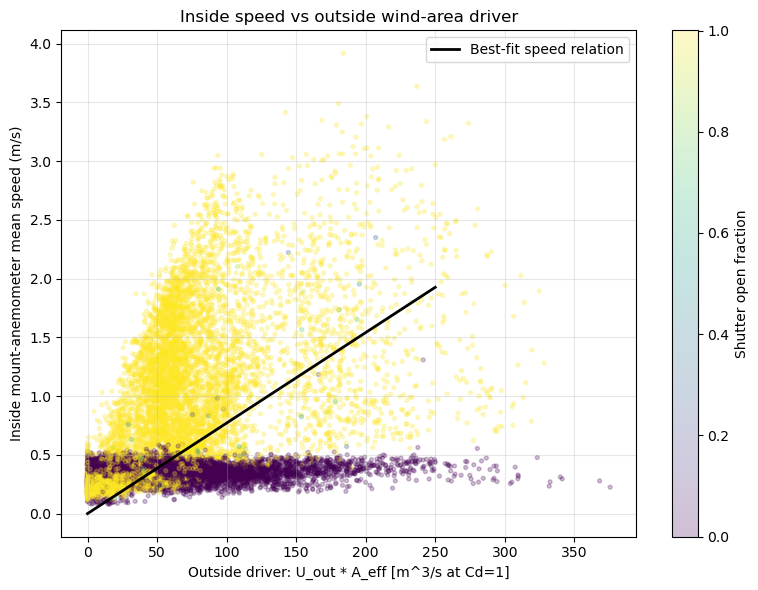

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    fit_df["outside_driver_m3s_cd1"],
    fit_df["inside_speed_mean_mps"],
    s=8,
    alpha=0.25,
    c=fit_df["shutter_open_fraction"],
    cmap="viridis",
)

x_line = np.linspace(0, fit_df["outside_driver_m3s_cd1"].quantile(0.99), 200)
ax.plot(x_line, speed_gain * x_line, color="black", lw=2.0, label="Best-fit speed relation")

ax.set_xlabel("Outside driver: U_out * A_eff [m^3/s at Cd=1]")
ax.set_ylabel("Inside mount-anemometer mean speed (m/s)")
ax.set_title("Inside speed vs outside wind-area driver")
ax.grid(True, alpha=0.3)
ax.legend()
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label("Shutter open fraction")
plt.tight_layout()
plt.show()

In [12]:
summary = pd.Series({
    "samples": len(fit_df),
    "outside_wind_mean_mps": fit_df["outside_wind_speed_mps"].mean(),
    "inside_speed_mean_mps": fit_df["inside_speed_mean_mps"].mean(),
    "effective_area_mean_m2": fit_df["effective_through_area_m2"].mean(),
    "effective_area_p90_m2": fit_df["effective_through_area_m2"].quantile(0.90),
    "outside_driver_mean_m3s_cd1": fit_df["outside_driver_m3s_cd1"].mean(),
    "speed_gain": speed_gain,
    "fitted_discharge_coefficient": fitted_cd,
})
display(summary.to_frame(name="value"))

display(
    fit_df[[
        "outside_wind_speed_mps",
        "outside_wind_dir_deg",
        "dome_azimuth_deg",
        "shutter_open_fraction",
        "windward_open_area_m2",
        "leeward_open_area_m2",
        "effective_through_area_m2",
        "inside_speed_mean_mps",
        "outside_driver_m3s_cd1",
    ]].head(20)
)

,value
samples,14112.000000
outside_wind_mean_mps,3.703219
inside_speed_mean_mps,0.716853
effective_area_mean_m2,20.140634
effective_area_p90_m2,28.150958
outside_driver_mean_m3s_cd1,71.199207
speed_gain,0.007704
fitted_discharge_coefficient,NaN


,outside_wind_speed_mps,outside_wind_dir_deg,dome_azimuth_deg,shutter_open_fraction,windward_open_area_m2,leeward_open_area_m2,effective_through_area_m2,inside_speed_mean_mps,outside_driver_m3s_cd1
2026-03-08 05:00:00+00:00,3.652225,20.532770,328.00293,0.0001,19.895305,26.110240,19.895305,0.271761,72.662131
2026-03-08 05:00:30+00:00,3.694983,23.606045,328.00293,0.0001,21.028653,26.799944,21.028653,0.281025,77.700509
2026-03-08 05:01:00+00:00,3.878100,22.455491,328.00293,0.0001,20.611270,26.550663,20.611270,0.225328,79.932565
2026-03-08 05:01:30+00:00,3.546313,23.314598,328.00293,0.0001,20.923721,26.737817,20.923721,0.252255,74.202065
2026-03-08 05:02:00+00:00,3.727617,19.326453,328.00293,0.0001,19.434619,25.818875,19.434619,0.256955,72.444823
2026-03-08 05:02:30+00:00,3.520175,30.139591,328.00293,0.0001,23.233240,28.007871,23.233240,0.302059,81.785071
2026-03-08 05:03:00+00:00,3.285235,22.380507,328.00293,0.0001,20.583778,26.534044,20.583778,0.233845,67.622542
2026-03-08 05:03:30+00:00,3.812075,11.654737,328.00293,0.0001,16.312094,23.703920,16.312094,0.230392,62.182925
2026-03-08 05:04:00+00:00,3.745748,13.174719,328.00293,0.0001,16.955805,24.157974,16.955805,0.274069,63.512169
2026-03-08 05:04:30+00:00,4.159575,23.746386,328.00293,0.0001,21.078988,26.829613,21.078988,0.225094,87.679629


,louver_type,count,static_area_m2,mean_windward_contrib_m2,mean_leeward_contrib_m2
0,1,12,26.00,9.821655,5.26618
1,2,10,39.48,7.016002,16.25804
2,3,2,0.00,0.000000,0.00000
3,4,2,0.00,0.000000,0.00000
4,5,2,0.00,0.000000,0.00000
5,6,2,0.00,0.000000,0.00000
6,7,2,0.00,0.000000,0.00000
7,8,2,0.00,0.000000,0.00000


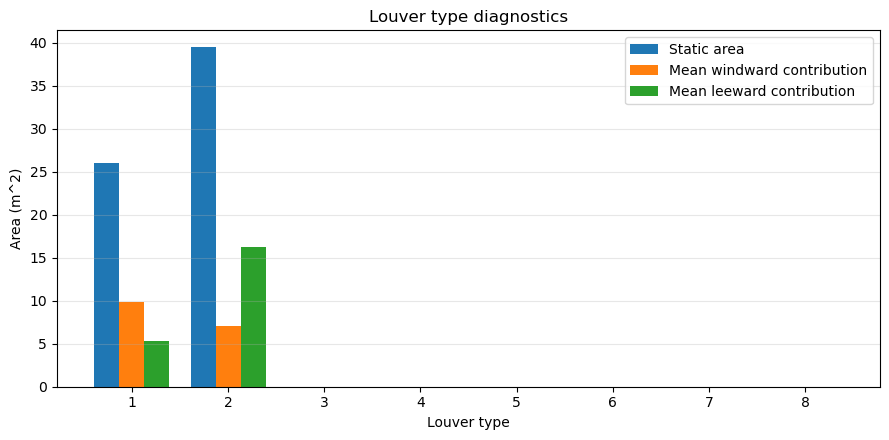

In [13]:
lmap = louver_map.copy()
if "louver_type" not in lmap.columns:
    raise ValueError("louver_type column not found in louver_map.csv. Add it to enable type diagnostics.")

lmap["louver_type"] = lmap["louver_type"].astype(int)
lmap["active_area_m2"] = lmap["full_open_area_m2"] * lmap["open_fraction"]

theta = np.deg2rad(model_df["outside_wind_dir_deg"].to_numpy(dtype=float)[:, None] - (model_df["dome_azimuth_deg"].to_numpy(dtype=float)[:, None] + lmap["azimuth_dome_deg"].to_numpy(dtype=float)[None, :]))
proj = np.cos(theta)
ain_mat = np.clip(proj, 0, None) * lmap["active_area_m2"].to_numpy(dtype=float)[None, :]
aout_mat = np.clip(-proj, 0, None) * lmap["active_area_m2"].to_numpy(dtype=float)[None, :]

type_rows = []
for t in sorted(lmap["louver_type"].unique()):
    mask = lmap["louver_type"].to_numpy() == t
    type_rows.append({
        "louver_type": int(t),
        "count": int(mask.sum()),
        "static_area_m2": float(lmap.loc[mask, "active_area_m2"].sum()),
        "mean_windward_contrib_m2": float(np.nanmean(ain_mat[:, mask].sum(axis=1))),
        "mean_leeward_contrib_m2": float(np.nanmean(aout_mat[:, mask].sum(axis=1))),
    })

type_diag = pd.DataFrame(type_rows).sort_values("louver_type").reset_index(drop=True)
display(type_diag)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(type_diag))
w = 0.26
ax.bar(x - w, type_diag["static_area_m2"], width=w, label="Static area")
ax.bar(x, type_diag["mean_windward_contrib_m2"], width=w, label="Mean windward contribution")
ax.bar(x + w, type_diag["mean_leeward_contrib_m2"], width=w, label="Mean leeward contribution")
ax.set_xticks(x)
ax.set_xticklabels(type_diag["louver_type"].astype(str))
ax.set_xlabel("Louver type")
ax.set_ylabel("Area (m^2)")
ax.set_title("Louver type diagnostics")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Airflow Efficiency vs Relative Wind Direction

Defines airflow efficiency as the inside-to-outside speed ratio:

`airflow_efficiency = inside_speed_mean_mps / outside_wind_speed_mps`

and plots it against relative wind direction:

`relative_wind_deg = wrap180(outside_wind_dir_deg - (dome_azimuth_deg + SHUTTER_AZIMUTH_OFFSET_DEG))`

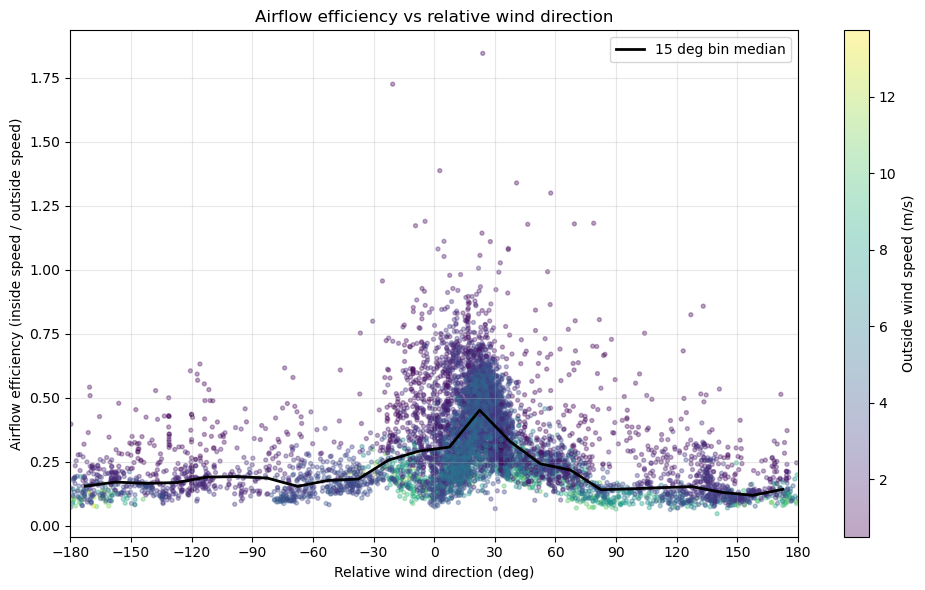

Points used: 7321
Median efficiency: 0.284
P10-P90 efficiency: 0.128 - 0.565


In [14]:
eff_df = model_df.copy()

eff_df["relative_wind_deg"] = wrap180(
    eff_df["outside_wind_dir_deg"] - (eff_df["dome_azimuth_deg"] + SHUTTER_AZIMUTH_OFFSET_DEG)
)
eff_df["airflow_efficiency"] = eff_df["inside_speed_mean_mps"] / eff_df["outside_wind_speed_mps"]

# Filter to physically useful points for stability in the ratio.
eff_df = eff_df[
    np.isfinite(eff_df["relative_wind_deg"])
    & np.isfinite(eff_df["airflow_efficiency"])
    & np.isfinite(eff_df["outside_wind_speed_mps"])
    & np.isfinite(eff_df["shutter_open_fraction"])
    & (eff_df["shutter_open_fraction"] > 0.95)
    & (eff_df["outside_wind_speed_mps"] > 0.5)
    & (eff_df["airflow_efficiency"] >= 0)
    & (eff_df["airflow_efficiency"] <= 3.0)
].copy()

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    eff_df["relative_wind_deg"],
    eff_df["airflow_efficiency"],
    c=eff_df["outside_wind_speed_mps"],
    cmap="viridis",
    s=8,
    alpha=0.35,
)

# Add a binned median trend to make directional structure easier to see.
bins = np.arange(-180, 181, 15)
centers = 0.5 * (bins[:-1] + bins[1:])
bin_idx = np.digitize(eff_df["relative_wind_deg"], bins) - 1
med = [eff_df.loc[bin_idx == i, "airflow_efficiency"].median() for i in range(len(centers))]
ax.plot(centers, med, color="black", lw=2, label="15 deg bin median")

ax.set_xlabel("Relative wind direction (deg)")
ax.set_ylabel("Airflow efficiency (inside speed / outside speed)")
ax.set_title("Airflow efficiency vs relative wind direction")
ax.set_xlim(-180, 180)
ax.set_xticks(np.arange(-180, 181, 30))
ax.grid(True, alpha=0.3)
ax.legend()

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Outside wind speed (m/s)")

plt.tight_layout()
plt.show()

print(f"Points used: {len(eff_df)}")
print(f"Median efficiency: {eff_df['airflow_efficiency'].median():.3f}")
print(f"P10-P90 efficiency: {eff_df['airflow_efficiency'].quantile(0.10):.3f} - {eff_df['airflow_efficiency'].quantile(0.90):.3f}")

## Next Refinements

Useful follow-ups once the notebook is running with your geometry map:

- Replace the static `open_fraction` column with time-dependent louver states if those are available
- Split the model by wind-relative dome angle, not just raw outside speed
- Compare top-ring sensors individually instead of only the across-sensor mean
- Fit separate coefficients for windward-only, shutter-only, and mixed aperture cases
- Add exposure metadata and image-quality metrics if you want to link flow state to observing performance

## Effective Area vs Relative Wind Bearing

Plots the effective louver and shutter area as a function of wind bearing angle relative to the shutter.

In [ ]:
def compute_areas_for_wind_angles(relative_wind_angles, louver_azimuths, louver_areas, shutter_full_open_area_m2):
    """Compute louver windward/leeward, shutter projected, and effective through areas for a sweep of wind angles."""
    n = len(relative_wind_angles)
    louver_windward   = np.zeros(n)
    louver_leeward    = np.zeros(n)
    shutter_proj      = np.zeros(n)
    effective_through = np.zeros(n)

    for i, wind_angle in enumerate(relative_wind_angles):
        rel  = wrap180(wind_angle - louver_azimuths)
        proj = np.cos(np.deg2rad(rel))
        louver_windward[i] = np.sum(louver_areas * np.clip(proj,  0, None))
        louver_leeward[i]  = np.sum(louver_areas * np.clip(-proj, 0, None))

        shutter_cos = np.cos(np.deg2rad(wind_angle))
        shutter_in  = shutter_full_open_area_m2 * max(shutter_cos,  0.0)
        shutter_out = shutter_full_open_area_m2 * max(-shutter_cos, 0.0)
        shutter_proj[i] = shutter_in

        effective_through[i] = min(louver_windward[i] + shutter_in,
                                   louver_leeward[i]  + shutter_out)

    return louver_windward, louver_leeward, shutter_proj, effective_through


def make_open_fractions(louver_map, open_ids):
    """Return open_fraction array with 1.0 for louver_ids in open_ids, else 0.0."""
    return np.where(louver_map["louver_id"].isin(open_ids), 1.0, 0.0)


# Sweep 0–360° then sort into –180…180 order for a clean x-axis
wind_angles_raw = np.linspace(0, 360, 721)
wind_deg_raw    = wrap180(wind_angles_raw)
sort_idx        = np.argsort(wind_deg_raw)
wind_deg        = wind_deg_raw[sort_idx]
wind_angles     = wind_angles_raw[sort_idx]

laz   = louver_map["azimuth_dome_deg"].to_numpy(dtype=float)
larea = louver_map["full_open_area_m2"].to_numpy(dtype=float)

# ── Three configurations ──────────────────────────────────────────────────────
configs = {
    "6 louvers + shutter (B1,E1,E2,H1,H2,M1)": [
        "B1", "E1", "E2", "H1", "H2", "M1"],
    "12 louvers + shutter (bottom row A1–N1)": [
        "A1", "B1", "C1", "D1", "E1", "F1", "G1", "H1", "I1", "L1", "M1", "N1"],
    "All 34 louvers + shutter":
        louver_map["louver_id"].tolist(),
}
colors     = ["tab:purple", "tab:red", "tab:gray"]
linestyles = ["--",          "-",      ":"]

fig, ax = plt.subplots(figsize=(13, 6))

# Shutter-only reference
shutter_curve = SHUTTER_FULL_OPEN_AREA_M2 * np.clip(np.cos(np.deg2rad(wind_angles)), 0, None)
ax.plot(wind_deg, shutter_curve, color="tab:cyan", lw=1.5, ls="--",
        label=f"Shutter only ({SHUTTER_FULL_OPEN_AREA_M2:.0f} m²)")

# Three louver+shutter configurations
for (label, ids), color, ls in zip(configs.items(), colors, linestyles):
    fracs        = make_open_fractions(louver_map, ids)
    active_areas = larea * fracs
    static_total = active_areas.sum()
    _, _, _, eff = compute_areas_for_wind_angles(wind_angles, laz, active_areas, SHUTTER_FULL_OPEN_AREA_M2)
    ax.plot(wind_deg, eff, color=color, lw=2.0, ls=ls,
            label=f"{label}  [{static_total:.0f} m² static]")

# All-louvers without shutter (faint reference for louver-only contribution)
_, _, _, eff_all_no_shutter = compute_areas_for_wind_angles(wind_angles, laz, larea, 0.0)
ax.plot(wind_deg, eff_all_no_shutter, color="tab:gray", lw=1.0, ls=":", alpha=0.5,
        label="All louvers only (no shutter)")

ax.set_xlabel("Wind bearing angle (° clockwise from shutter)")
ax.set_ylabel("Effective normal clear area (m²)")
ax.set_title("Effective aperture area vs relative wind direction")
ax.set_xlim(-180, 180)
ax.set_xticks(np.arange(-180, 181, 30))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()